In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss

from matplotlib import cm
from matplotlib.ticker import LinearLocator

In [3]:
# Make data.
mu = 5
sd = 2

x = np.arange(-2.5, 12.5, 0.1)
y = np.arange(-5, 10, 0.1)
X, Y = np.meshgrid(x, y)

nPRF_func = ss.norm(loc=mu, scale=sd).pdf(x) * 20

In [4]:
Z = []
for i, x_i in enumerate(x):
    mu = nPRF_func[i]
    distr = ss.norm(loc=mu, scale=sd).pdf(y)
    Z.append(distr)

Z = np.array(Z)    

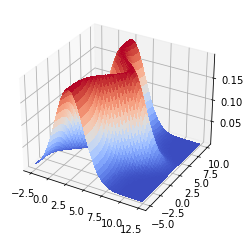

In [5]:
# Plot the surface.
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

In [6]:
import plotly.graph_objects as go
import plotly.express as px

fig = go.Figure(data=[go.Surface(z=Z, surfacecolor = Y, colorscale=px.colors.sequential.Rainbow)] )#coloraxis

fig.show()

In [13]:
x = np.arange(-2.5, 12.5, 0.1)
y = np.arange(-5, 10, 0.1)
X, Y = np.meshgrid(x, y)

mu = 5
sd = 2
nPRF_func = ss.norm(loc=mu, scale=sd).pdf(x) * 20

Z = []
for i, x_i in enumerate(x):
    mu = nPRF_func[i]
    distr = ss.norm(loc=mu, scale=sd).pdf(y)
    Z.append(distr)

Z = np.array(Z)   

In [25]:
fig = go.Figure(data=[go.Surface(z=Z.T, y=Y,x=X,surfacecolor = X, colorscale=px.colors.sequential.Rainbow)] )#coloraxis

fig.update_layout(
        scene = {
            "xaxis": {"nticks": 5},
            "yaxis": {"nticks": 3},
            "zaxis": {"nticks": 3},
            'camera_eye': {"x": 0, "y": -1, "z": 0.5},
            "aspectratio": {"x": 1, "y": 1, "z": 0.4}
        })
#fig.add_hline(y=0, z=0)

#fig.add_scatter3d(x=np.array([0,0]), y = np.array([0,0]), z = np.array([0,0.5]), mode='lines', marker_colorbar_bordercolor='black' ) #,width=2 
#fig.update_traces(opacity=0.9, selector=dict(type='surface'))
fig.show()